## **Wealth Management engineering**
WELSCH Nathan & TARILLON-KIEFFER Liam




## **1. Project Objective**

The objective of this project is to construct an optimal investment portfolio for a high-net-worth (HNW) client using Modern Portfolio Theory (MPT) and Markowitz mean-variance optimization. The portfolio aims to maximize the risk-adjusted return (Sharpe ratio) while respecting specific risk and allocation constraints. Real-time market data will be used to determine the optimal allocation across equities and gold.

## **2. Client Context**

The client is a high-net-worth private investor seeking long-term capital growth with controlled exposure to equity market risk. The investment capital available for allocation is €1,000,000. The client prefers a diversified portfolio focused on large-cap equities, complemented by gold as a safe-haven asset to reduce systemic risk during periods of market stress. Bonds, derivatives, and crypto-assets are explicitly excluded from the investment universe.

## **3. Investment Policy Statement (IPS)**

### 3.1 - Investor Profile

The client is an informed investor with a long-term horizon of 10 to 15 years. Short-term liquidity needs are low. The investor is willing to accept high equity exposure while seeking stable long-term capital growth.

### 3.2 - Investment Objectives

The primary objective is to maximize the portfolio’s risk-adjusted performance, targeting an annual return of approximately 6%, above the risk-free rate, while ensuring stable value creation over the long term.

### 3.3 - Investment Horizon

The investment horizon is 10 to 15 years, with annual portfolio rebalancing planned to maintain the target allocation. Short-term liquidity needs remain low.

### 3.4 - Risk Tolerance

The client accepts high equity risk but expects diversification through gold allocation to partially hedge market downturns. The portfolio must comply with the following risk constraints:

>Maximum annual volatility: 15%

>Maximum tolerable loss (Max Drawdown): -25%

>Value-at-Risk (95% confidence): < 10%

### 3.5 - Allocation Constraints

The portfolio is subject to the following rules:

>No short selling

>Maximum weight per asset: 30%

>Minimum weight per asset: 0%

>Number of assets: between 5 and 10

>Fully invested portfolio: sum of weights = 100%

### 3.6 - Investment Universe

The portfolio will consist exclusively of:

>Equities: American, European, and emerging market large caps

>Commodities: Gold via ETFs

Excluded from the investment universe are bonds, derivatives, and crypto-assets.

### 3.7 - Benchmark

The portfolio will be compared against a passive benchmark consisting of:

>80% global equities (MSCI World index)

>20% gold (GLD ETF)

The benchmark is rebalanced annually to ensure consistency with the optimized portfolio. The risk-free rate corresponds to the French 10-year government bond yield, set at 3.447% as of 06/02/2026.

### 3.8 - Allocation Method

The optimal portfolio allocation will be determined using a Markowitz mean-variance optimization model, integrating all risk, allocation, and diversification constraints outlined in this IPS.

# Librairies importation

In [1]:
import yfinance as yf
import pandas as pd
import pandas_datareader as pdr
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
from scipy.stats import norm, jarque_bera

## 1. Data extraction from the MSCI World Acc ETF

In [2]:
def filtrage_ETF(etf_ticker_placeholder):
    # Placeholder list of common stock tickers to simulate ETF holdings
    placeholder_tickers = list(set([
        'NVDA','AAPL','MSFT','AMZN','GOOGL','GOOG','META','AVGO','TSLA','LLY','JPM','UNH','XOM','V','MA','COST','ORCL','HD','PG',
        'NFLX','ABBV','BAC','SAP','ASML','CRM','WMT','KO','CVX','TM','ADBE','PEP','MRK','LIN','TMO','WFC','MCD','ACN','CSCO','ABT',
        'DIS','QCOM','GE','INTU','DHR','CAT','VZ','TXN','IBM','AMAT','AXP','PFE','MS','PM','AMGN','GS','ISRG','NOW','HON','RTX','LOW',
        'BKNG','SPGI','INTC','SYK','C','TJX','PGR','BLK','ELV','REGN','SCHW','VRTX','ETN','BSX','LMT','ADI','PANW','MDLZ','CB','CI',
        'MMC','BA','MU','PLTR','GILD','ADP','LRCX','DE','VRT','T','WM','AMT','MDT','ZTS','ICE','SBUX','MO','ITW','SHW','ANET','CVS',
        'HCA','BX','EQIX','ECL','PH','GD','MCK','ORLY','CDNS','MAR','NXPI','CTAS','BDX','APH','MCO','TGT','F','EMR','ADSK','ROP','TDG',
        'KLAC','AON','CMG','PNC','TEL','MET','CARR','SNPS','EW','DASH','APO','DLR','AJG','MCHP','COF','MSI','GWW','TRV','HUM','AIG',
        'ALL','CPRT','USB','O','STZ','MPC','KMB','VRSK','AZO','FMS','NSC','NEM','GLW','PAYX','GEV','IT','KMI','KDP','WMB','BKR','WELL',
        'DOW','A','PRU','STT','OTIS','FAST','KR','CEG','ODFL','CTVA','ED','VICI','BBY','EIX','HPQ','DD','HAL','VLO','OKE','TRGP','MTD',
        'KEYS','K','FITB','EFX','EBAY','WST','WDC','ROK','GPN','FICO','ZBRA','TER','ALGN','VTR','AVB','EQR','ARE','INVH','SBAC','EXR',
        'MAA','CPT','BXP','UDR','DOC','REG','KIM','FRT','HST','STAG','NNN','WPC','ADC','PLD','SPG'
    ]))

    print(f"Analyzing simulated holdings for ETF: {etf_ticker_placeholder}")
    print(f"Tickers to analyze: {len(placeholder_tickers)}")

    # Define date range for 5 years of historical data
    endDate = dt.datetime.now()
    startDate = endDate - dt.timedelta(days=365*5)

    # Download adjusted close prices for all tickers
    data = yf.download(
        placeholder_tickers,
        start=startDate,
        end=endDate,
        auto_adjust=False,
        threads=True,
        progress=False
    )['Adj Close']

    # Keep only tickers with at least 80% of historical data
    min_data_points = int(len(data) * 0.8)
    data = data.dropna(thresh=min_data_points, axis=1)
    print(f"Downloaded historical data for {data.shape[1]} tickers from {startDate.strftime('%Y-%m-%d')} to {endDate.strftime('%Y-%m-%d')}.")

    # Calculate daily log returns
    log_returns = np.log(data / data.shift(1)).dropna()
    print(f"Calculated daily log returns for {log_returns.shape[1]} tickers. Shape: {log_returns.shape}")

    # Risk-free rate
    rf = 0.03447

    # Annualized returns and volatility
    annual_mean_returns = log_returns.mean() * 252
    annual_std_dev = log_returns.std() * np.sqrt(252)

    # Sharpe ratios
    sharpe_ratios = (annual_mean_returns - rf) / annual_std_dev
    print(f"Calculated Sharpe ratios for {len(sharpe_ratios)} tickers.")

    # Top 10 tickers by Sharpe ratio
    top_10_sharpe_info = sharpe_ratios.nlargest(10)
    print(f"Top 10 tickers based on Sharpe Ratio:\n{top_10_sharpe_info}")

    # Horizontal bar chart
    plt.figure(figsize=(10,6))
    top_10_sharpe_info.sort_values().plot(kind='barh', color='skyblue')
    plt.title(f"Top 10 Sharpe Ratios - {etf_ticker_placeholder}")
    plt.xlabel("Sharpe Ratio")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    return top_10_sharpe_info


Analyzing simulated holdings for ETF: Amundi Core MSCI World UCITS ETF Acc
Tickers to analyze: 219
Downloaded historical data for 218 tickers from 2021-02-12 to 2026-02-11.
Calculated daily log returns for 218 tickers. Shape: (977, 218)
Calculated Sharpe ratios for 218 tickers.
Top 10 tickers based on Sharpe Ratio:
Ticker
GE      1.181716
MCK     1.162340
AVGO    1.122624
CEG     1.092003
APH     1.051775
LLY     1.045252
IBM     0.961001
PLTR    0.920515
WMT     0.907888
TRGP    0.895446
dtype: float64


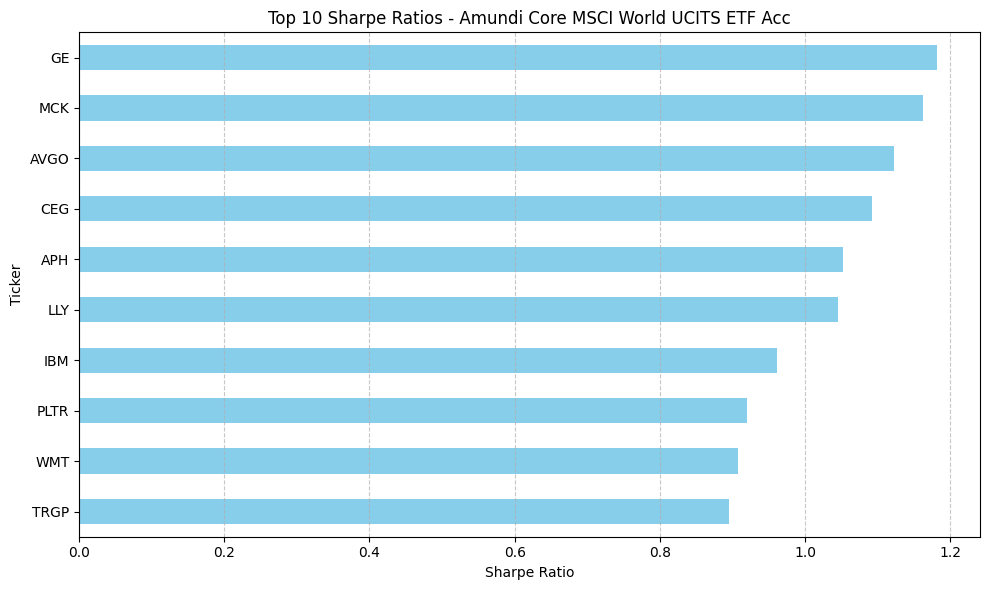

In [3]:
top_sharpe_stocks = filtrage_ETF("Amundi Core MSCI World UCITS ETF Acc")

##2. Dynamic Dashboard construction

In [4]:
#Annualized volatility
def standard_dev(weights, cov_matrix):
  variance=weights.T @ cov_matrix @ weights #multiplying a matrix with weight ponderation
  return np.sqrt(variance)

In [5]:
#Annualized return
def expected_returns(weights,log_returns):
  return np.sum(log_returns.mean()*weights)*252

In [6]:
#Sharpe Ratio
def Sharpe_ratio(weights,log_returns,cov_matrix,rf):
  return (expected_returns(weights,log_returns)-rf)/standard_dev(weights,cov_matrix)

In [7]:
#Value at Risk
def plot_var_distribution(returns_dollar, VaR, confidence_interval, days, title):
  plt.hist(returns_dollar.dropna(), bins=50, color='skyblue', edgecolor='black', density=True)
  plt.xlabel(f'{days}- Day Portfolio Return (Dollar Value)')
  plt.ylabel('Frequency')
  plt.title(title)
  plt.axvline(x=-VaR, color='red', linestyle='--', label=f'VaR {confidence_interval*100}%')
  plt.legend()
  plt.show()

def Value_at_risk(returns_percentage, confidence_interval, portfolio_value):
  # Calculate VaR based on historical returns (percentage)
  # For example, using the percentile method
  return -np.percentile(returns_percentage, (1 - confidence_interval) * 100) * portfolio_value

def VaR_parametric_constraint_func(weights, log_returns, confidence_interval, days):
  # Calculate portfolio daily mean return
  portfolio_mean_daily_return = np.sum(log_returns.mean() * weights)

  # Calculate portfolio daily standard deviation

  portfolio_daily_std_dev = np.sqrt(np.dot(weights.T, np.dot(log_returns.cov(), weights))) # This should use daily cov, not annualized

  # Calculate VaR for 'days' period

  alpha = 1 - confidence_interval
  z_score = norm.ppf(alpha)

  VaR_percent = -(portfolio_mean_daily_return * days + z_score * portfolio_daily_std_dev * np.sqrt(days))
  return VaR_percent

In [8]:
#Max drawdown

def summarize_max_drawdown(cumulative_returns):
    # Calculate the running maximum (peak) of the cumulative returns
    running_max = cumulative_returns.expanding(min_periods=1).max()

    # Calculate the drawdown
    drawdown = (cumulative_returns - running_max) / running_max

    # Calculate the maximum drawdown
    max_drawdown = drawdown.min()

    print(f"  Maximum Drawdown: {max_drawdown:.4f}")
    return max_drawdown

In [9]:
#Calculation of Skewness & Kurtosis

def summarize_distribution_moments(optimal_returns, equal_returns):
    print("Optimal Portfolio:")
    print(f"  Skewness: {optimal_returns.skew():.4f}")
    print(f"  Kurtosis: {optimal_returns.kurt():.4f}")

    print("\nEqually Weighted Portfolio:")
    print(f"  Skewness: {equal_returns.skew():.4f}")
    print(f"  Kurtosis: {equal_returns.kurt():.4f}")

In [10]:
def summarize_all_portfolio_analysis(tickers):
    # Suppress FutureWarning from yfinance
    warnings.filterwarnings('ignore', category=FutureWarning)

    # Defining the date range
    endDate = dt.datetime.now()
    startDate = endDate - dt.timedelta(days=365 * 5)

    # Fixed factors, updated to match IPS
    rf = 0.03447  # Updated to match IPS: 3.447%
    confidence_interval = 0.95  # Updated to match IPS: 95% for VaR
    portfolio_value = 10000
    days = 5
    num_simulations = 1000
    num_days = 252 # Number of trading days in a year for simulation period

    # Download close prices
    close_df = pd.DataFrame()
    for ticker in tickers:
        data = yf.download(ticker, start=startDate, end=endDate, progress=False, auto_adjust=False)
        close_df[ticker] = data['Adj Close']

    # Calculate log returns
    log_returns = np.log(close_df / close_df.shift(1)).dropna()

    # Calculate covariance matrix for optimization
    cov_matrix_opt = log_returns.cov() * 252 # Annualized covariance

    # Constraints and bounds for optimization, updated to match IPS
    # Poids maximum par actif : 30 % -> upper bound 0.30
    # Poids minimum par actif : 0% -> lower bound 0
    bounds = [(0.0, 0.30) for _ in range(len(tickers))]

    # Define constraints list
    constraints = [
        {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}, # Sum of weights = 1

        # Volatility constraint: Annual Volatility <= 0.15
        {'type': 'ineq', 'fun': lambda weights: 0.15 - standard_dev(weights, cov_matrix_opt)},

        # Parametric VaR constraint: VaR (percentage) <= 0.10 (10%)
        {'type': 'ineq', 'fun': lambda weights: 0.10 - VaR_parametric_constraint_func(weights, log_returns, confidence_interval, days)}
    ]

    # Initial weights
    initial_weights = np.array([1 / len(tickers) for _ in range(len(tickers))])

    # Optimize the weights
    optimized_results = minimize(lambda weights: -Sharpe_ratio(weights, log_returns, cov_matrix_opt, rf),
                                 initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)
    print("-- Optimal weights --")

    optimal_weights = optimized_results.x

    optimal_portfolio_returns = expected_returns(optimal_weights, log_returns)
    optimal_portfolio_std = standard_dev(optimal_weights, cov_matrix_opt)
    optimal_sharpe_ratio = Sharpe_ratio(optimal_weights, log_returns, cov_matrix_opt, rf)

    print("Optimal Weights:")
    for ticker, weight in zip(tickers, optimal_weights):
        print(f"{ticker}: {weight:.4f}")

    print(f"\nExpected Returns: {optimal_portfolio_returns:.4f}")
    print(f"Standard Deviation: {optimal_portfolio_std:.4f}")
    print(f"Sharpe Ratio: {optimal_sharpe_ratio:.4f}")

    print("\n--- IPS Constraint Checks for Optimal Portfolio ---")

    # 1. Volatility Constraint Check
    volatility_limit = 0.15
    print(f"Annual Volatility (Target max {volatility_limit*100:.0f}%) : {optimal_portfolio_std*100:.2f}%")
    if optimal_portfolio_std < volatility_limit:
        print("  Status: Respected")
    else:
        print("  Status: Violated")

    # Calculate number of assets
    num_assets = len(tickers)

    # Create an equal_weights NumPy array
    equal_weights = np.array([1/num_assets for _ in range(num_assets)])

    # Calculate expected returns for equally weighted portfolio
    equal_weighted_returns = expected_returns(equal_weights, log_returns)

    print("\n--- Expected Returns results ---")

    print(f"\nExpected Returns (Optimal Portfolio): {optimal_portfolio_returns:.4f}")
    print(f"Expected Returns (Equally Weighted Portfolio): {equal_weighted_returns:.4f}")

    print("\n--- Historical VaR Analysis ---")
    # Call summarize_historical_var
    def summarize_historical_var_updated(log_returns, optimal_weights, equal_weights, confidence_interval, portfolio_value, days):
        historical_optimal_returns = (log_returns * optimal_weights).sum(axis=1)
        range_optimal_returns = historical_optimal_returns.rolling(window=days).sum().dropna()
        range_optimal_returns_dollar = range_optimal_returns * portfolio_value

        historical_equal_returns = (log_returns * equal_weights).sum(axis=1)
        range_equal_returns = historical_equal_returns.rolling(window=days).sum().dropna()
        range_equal_returns_dollar = range_equal_returns * portfolio_value

        VaR_optimized = Value_at_risk(range_optimal_returns, confidence_interval, portfolio_value)
        VaR_equally_weighted = Value_at_risk(range_equal_returns, confidence_interval, portfolio_value)

        print(f"VaR for Optimal Portfolio: -${VaR_optimized:.2f}")
        print(f"VaR for Equally Weighted Portfolio: -${VaR_equally_weighted:.2f}")

        plot_var_distribution(range_optimal_returns_dollar, VaR_optimized, confidence_interval, days, f'Distribution of Optimized Portfolio {days}-Day Returns (Dollar Value)')
        plot_var_distribution(range_equal_returns_dollar, VaR_equally_weighted, confidence_interval, days, f'Distribution of Equally Weighted Portfolio {days}-Day Returns (Dollar Value)')

        return VaR_optimized, VaR_equally_weighted, historical_optimal_returns, historical_equal_returns

    VaR_optimal, VaR_equal, historical_optimal_returns, historical_equal_returns = \
        summarize_historical_var_updated(log_returns, optimal_weights, equal_weights, confidence_interval, portfolio_value, days)

    # 3. Value at Risk Constraint Check (Historical VaR for consistency with previous checks)
    VaR_limit_percentage = 0.10
    VaR_percentage_optimal = VaR_optimal / portfolio_value
    print(f"Value at Risk (Target max {VaR_limit_percentage*100:.0f}%) : {VaR_percentage_optimal*100:.2f}%")
    if VaR_percentage_optimal < VaR_limit_percentage:
        print("  Status: Respected")
    else:
        print("  Status: Violated")


    print("\n--- Maximum Drawdown Analysis ---")

    cumulative_optimal_returns = historical_optimal_returns.cumsum()
    print("Optimal Portfolio:")
    # Calculate max drawdown for optimal portfolio here to check constraint
    max_drawdown_optimal = summarize_max_drawdown(cumulative_optimal_returns)
    # 2. Maximum Drawdown Constraint Check
    max_drawdown_limit = -0.25
    print(f"Maximum Drawdown (Target max {max_drawdown_limit*100:.0f}%) : {max_drawdown_optimal*100:.2f}%")
    if max_drawdown_optimal > max_drawdown_limit: # Max drawdown is a negative value, so ">" means less severe loss
        print("  Status: Respected")
    else:
        print("  Status: Violated")

    cumulative_equal_returns = historical_equal_returns.cumsum()
    print("Equally Weighted Portfolio:")
    summarize_max_drawdown(cumulative_equal_returns) # This will print max drawdown for equal portfolio

    print("\n--- Distribution Moments ---")
    summarize_distribution_moments(historical_optimal_returns, historical_equal_returns)

    # --- Jarque-Bera Normality Test ---
    print("\n--- Jarque-Bera Normality Test ---")
    jb_optimal = jarque_bera(historical_optimal_returns)
    jb_equal = jarque_bera(historical_equal_returns)

    print("Optimal Portfolio Returns - Jarque-Bera Test:")
    print(f"  Statistic: {jb_optimal[0]:.4f}")
    print(f"  p-value: {jb_optimal[1]:.4f}")
    if jb_optimal[1] < 0.05: # Common significance level
        print("  Conclusion: Reject null hypothesis of normality (Not Normal)\n")
    else:
        print("  Conclusion: Fail to reject null hypothesis of normality (Normal or close to Normal)\n")

    print("Equally Weighted Portfolio Returns - Jarque-Bera Test:")
    print(f"  Statistic: {jb_equal[0]:.4f}")
    print(f"  p-value: {jb_equal[1]:.4f}")
    if jb_equal[1] < 0.05:
        print("  Conclusion: Reject null hypothesis of normality (Not Normal)\n")
    else:
        print("  Conclusion: Fail to reject null hypothesis of normality (Normal or close to Normal)\n")

    # --- Benchmark Portfolio Calculation ---
    print("\n--- Benchmark Portfolio Analysis ---")
    benchmark_tickers = ['IWDA.AS', 'GLD']
    benchmark_weights = {'IWDA.AS': 0.8, 'GLD': 0.2}

    benchmark_close_df = pd.DataFrame()
    for ticker in benchmark_tickers:
        data = yf.download(ticker, start=startDate, end=endDate, progress=False, auto_adjust=False)
        benchmark_close_df[ticker] = data['Adj Close']

    benchmark_log_returns = np.log(benchmark_close_df / benchmark_close_df.shift(1)).dropna()

    # Align benchmark returns with the existing log_returns index
    common_index = log_returns.index.intersection(benchmark_log_returns.index)
    aligned_benchmark_log_returns = benchmark_log_returns.reindex(common_index)

    # Calculate historical weighted returns for the benchmark
    historical_benchmark_returns = (
        aligned_benchmark_log_returns['IWDA.AS'] * benchmark_weights['IWDA.AS']
    ) + (
        aligned_benchmark_log_returns['GLD'] * benchmark_weights['GLD']
    )

    cumulative_benchmark_returns = historical_benchmark_returns.cumsum()
    print(f"Cumulative returns for Benchmark Portfolio (80% MSCI World, 20% Gold):\n{cumulative_benchmark_returns.iloc[-1]:.4f}")

    # Recalculate benchmark portfolio std for efficient frontier plot
    # Create a NumPy array for benchmark weights in the correct order based on aligned_benchmark_log_returns columns
    benchmark_weights_array = np.array([benchmark_weights[t] for t in aligned_benchmark_log_returns.columns])
    benchmark_portfolio_returns = expected_returns(benchmark_weights_array, aligned_benchmark_log_returns)
    benchmark_portfolio_std = standard_dev(benchmark_weights_array, aligned_benchmark_log_returns.cov() * 252)


    # --- Plotting Cumulative Returns ---
    plt.figure(figsize=(12, 6))
    plt.plot(cumulative_optimal_returns.index, cumulative_optimal_returns, label='Optimal Portfolio Cumulative Returns', color='blue')
    plt.plot(cumulative_equal_returns.index, cumulative_equal_returns, label='Equally Weighted Portfolio Cumulative Returns', color='green')
    plt.plot(cumulative_benchmark_returns.index, cumulative_benchmark_returns, label='Benchmark Portfolio Cumulative Returns (80% IWDA.AS, 20% GLD)', color='red')
    plt.title('Cumulative Returns Comparison')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Log Returns')
    plt.legend()
    plt.grid(True)
    plt.show()

    print("\n--- Efficient Frontier Analysis ---")

    # Define function for simulating random portfolios
    def simulate_random_portfolios(num_portfolios, log_returns, cov_matrix_opt, rf):
        portfolio_returns = []
        portfolio_volatilities = []
        portfolio_sharpe_ratios = []

        num_assets = len(log_returns.columns)

        for _ in range(num_portfolios):
            weights = np.random.random(num_assets)
            weights /= np.sum(weights) # Normalize weights to sum to 1

            # Implement allocation constraints: max weight 0.30 per asset
            # Regenerate if any weight exceeds 0.30
            # This is a simple approach, more sophisticated methods could be used
            while np.any(weights > 0.30):
                weights = np.random.random(num_assets)
                weights /= np.sum(weights)

            # Calculate portfolio metrics
            ret = expected_returns(weights, log_returns)
            vol = standard_dev(weights, cov_matrix_opt)
            sharpe = Sharpe_ratio(weights, log_returns, cov_matrix_opt, rf)

            portfolio_returns.append(ret)
            portfolio_volatilities.append(vol)
            portfolio_sharpe_ratios.append(sharpe)

        return np.array(portfolio_returns), np.array(portfolio_volatilities), np.array(portfolio_sharpe_ratios)

    # Define function for plotting the efficient frontier
    def plot_efficient_frontier(random_volatilities, random_returns, random_sharpe_ratios,
                               optimal_volatility, optimal_return,
                               benchmark_volatility, benchmark_return):
        plt.figure(figsize=(12, 8))
        # Plot random portfolios, colored by Sharpe Ratio
        scatter = plt.scatter(random_volatilities, random_returns, c=random_sharpe_ratios, cmap='viridis', s=10, alpha=0.6, label='Random Portfolios')
        plt.colorbar(scatter, label='Sharpe Ratio')

        # Plot optimal portfolio
        plt.scatter(optimal_volatility, optimal_return, color='red', marker='*', s=300, label='Optimal Portfolio (Max Sharpe Ratio)')

        # Plot benchmark portfolio
        plt.scatter(benchmark_volatility, benchmark_return, color='purple', marker='X', s=200, label='Benchmark Portfolio')

        plt.title('Efficient Frontier with Random, Optimal, and Benchmark Portfolios')
        plt.xlabel('Annualized Volatility (Standard Deviation)')
        plt.ylabel('Annualized Expected Return')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    num_portfolios = 10000
    random_port_returns, random_port_volatilities, random_port_sharpe_ratios = simulate_random_portfolios(
        num_portfolios, log_returns, cov_matrix_opt, rf
    )

    plot_efficient_frontier(random_port_volatilities, random_port_returns, random_port_sharpe_ratios,
                            optimal_portfolio_std, optimal_portfolio_returns,
                            benchmark_portfolio_std, benchmark_portfolio_returns)

    print("\n--- Monte Carlo Simulation (Bootstrap) ---")

    # Get number of historical observations
    n_historical_days = len(log_returns)

    plt.figure(figsize=(15, 7))

    # --- Optimal Portfolio Simulation ---
    simulated_optimal_portfolio_values = np.zeros((num_days, num_simulations))
    for s in range(num_simulations):
        # Bootstrap: randomly select num_days rows from historical log_returns with replacement
        random_indices = np.random.choice(n_historical_days, num_days, replace=True)
        bootstrapped_daily_returns = log_returns.iloc[random_indices]

        # Calculate portfolio daily returns using bootstrapped returns and optimal weights
        portfolio_daily_returns_optimal = np.dot(bootstrapped_daily_returns, optimal_weights)
        simulated_optimal_portfolio_values[:, s] = portfolio_value * np.exp(np.cumsum(portfolio_daily_returns_optimal))

    plt.subplot(1, 2, 1)
    plt.plot(simulated_optimal_portfolio_values)
    plt.title(f'Optimal Portfolio Monte Carlo Simulation (Bootstrap, {num_simulations} runs)')
    plt.xlabel('Days')
    plt.ylabel('Portfolio Value')
    plt.grid(True)

    # --- Equally Weighted Portfolio Simulation ---
    simulated_equal_portfolio_values = np.zeros((num_days, num_simulations))
    for s in range(num_simulations):
        # Bootstrap: randomly select num_days rows from historical log_returns with replacement
        random_indices = np.random.choice(n_historical_days, num_days, replace=True)
        bootstrapped_daily_returns = log_returns.iloc[random_indices]

        # Calculate portfolio daily returns using bootstrapped returns and equal weights
        portfolio_daily_returns_equal = np.dot(bootstrapped_daily_returns, equal_weights)
        simulated_equal_portfolio_values[:, s] = portfolio_value * np.exp(np.cumsum(portfolio_daily_returns_equal))

    plt.subplot(1, 2, 2)
    plt.plot(simulated_equal_portfolio_values)
    plt.title(f'Equally Weighted Portfolio Monte Carlo Simulation (Bootstrap, {num_simulations} runs)')
    plt.xlabel('Days')
    plt.ylabel('Portfolio Value')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


    # --- Summary Statistics for Final Portfolio Values ---
    final_optimal_values = simulated_optimal_portfolio_values[-1, :]
    final_equal_values = simulated_equal_portfolio_values[-1, :]

    print("\n--- Summary Statistics for Final Portfolio Values ---")
    print("Optimal Portfolio:")
    print(f"  Mean: ${np.mean(final_optimal_values):.2f}")
    print(f"  Median: ${np.median(final_optimal_values):.2f}")
    print(f"  Standard Deviation: ${np.std(final_optimal_values):.2f}")
    print(f"  Minimum: ${np.min(final_optimal_values):.2f}")
    print(f"  Maximum: ${np.max(final_optimal_values):.2f}")

    print("\nEqually Weighted Portfolio:")
    print(f"  Mean: ${np.mean(final_equal_values):.2f}")
    print(f"  Median: ${np.median(final_equal_values):.2f}")
    print(f"  Standard Deviation: ${np.std(final_equal_values):.2f}")
    print(f"  Minimum: ${np.min(final_equal_values):.2f}")
    print(f"  Maximum: ${np.max(final_equal_values):.2f}")

    print("\n--- Comprehensive Portfolio Analysis Complete ---")

We use a Bootstraping method for the Monte Carlo simulation because the jarque Bera test found that the two distributions are not normally distributed

-- Optimal weights --
Optimal Weights:
GE: 0.0984
MCK: 0.2461
AVGO: 0.0478
CEG: 0.0111
APH: 0.0000
LLY: 0.0975
IBM: 0.0257
PLTR: 0.0155
WMT: 0.1265
TRGP: 0.0314
GLD: 0.3000

Expected Returns: 0.3155
Standard Deviation: 0.1301
Sharpe Ratio: 2.1602

--- IPS Constraint Checks for Optimal Portfolio ---
Annual Volatility (Target max 15%) : 13.01%
  Status: Respected

--- Expected Returns results ---

Expected Returns (Optimal Portfolio): 0.3155
Expected Returns (Equally Weighted Portfolio): 0.3652

--- Historical VaR Analysis ---
VaR for Optimal Portfolio: -$240.20
VaR for Equally Weighted Portfolio: -$377.74


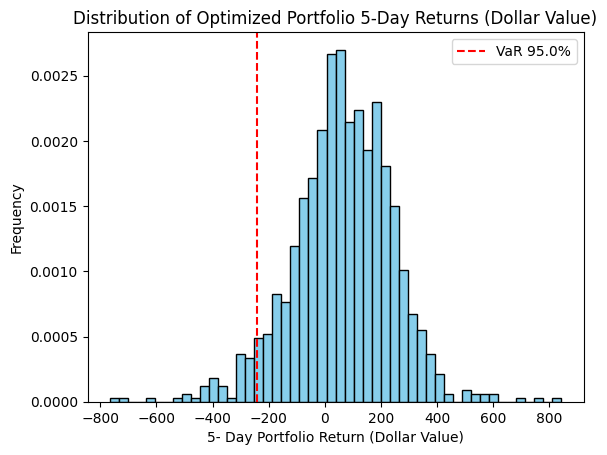

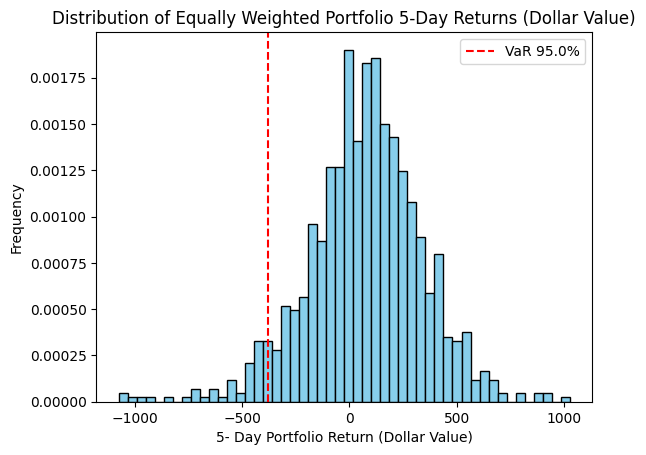

Value at Risk (Target max 10%) : 2.40%
  Status: Respected

--- Maximum Drawdown Analysis ---
Optimal Portfolio:
  Maximum Drawdown: -1.0861
Maximum Drawdown (Target max -25%) : -108.61%
  Status: Violated
Equally Weighted Portfolio:
  Maximum Drawdown: -2.1504

--- Distribution Moments ---
Optimal Portfolio:
  Skewness: -0.2649
  Kurtosis: 5.3293

Equally Weighted Portfolio:
  Skewness: -0.2732
  Kurtosis: 5.4316

--- Jarque-Bera Normality Test ---
Optimal Portfolio Returns - Jarque-Bera Test:
  Statistic: 1202.1409
  p-value: 0.0000
  Conclusion: Reject null hypothesis of normality (Not Normal)

Equally Weighted Portfolio Returns - Jarque-Bera Test:
  Statistic: 1249.0631
  p-value: 0.0000
  Conclusion: Reject null hypothesis of normality (Not Normal)


--- Benchmark Portfolio Analysis ---
Cumulative returns for Benchmark Portfolio (80% MSCI World, 20% Gold):
0.5211


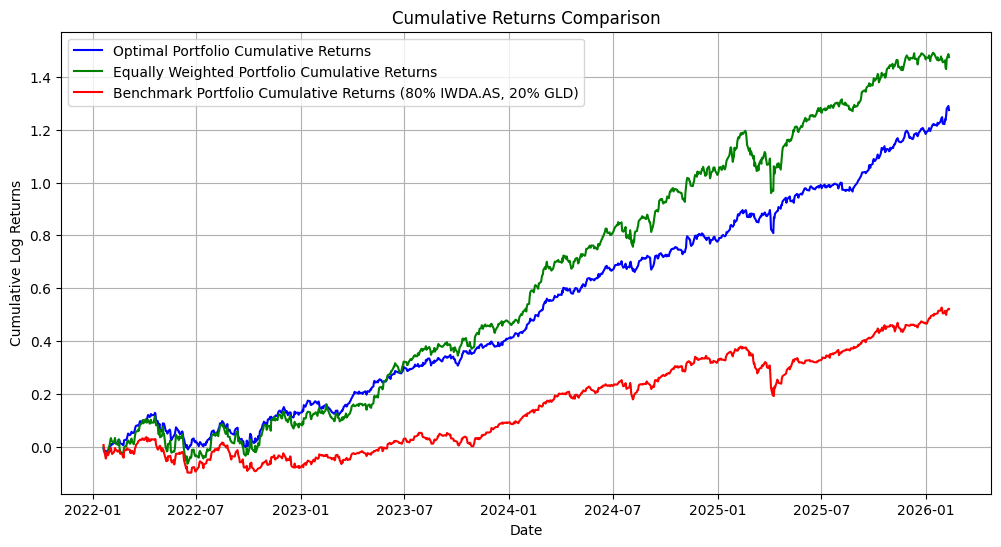


--- Efficient Frontier Analysis ---


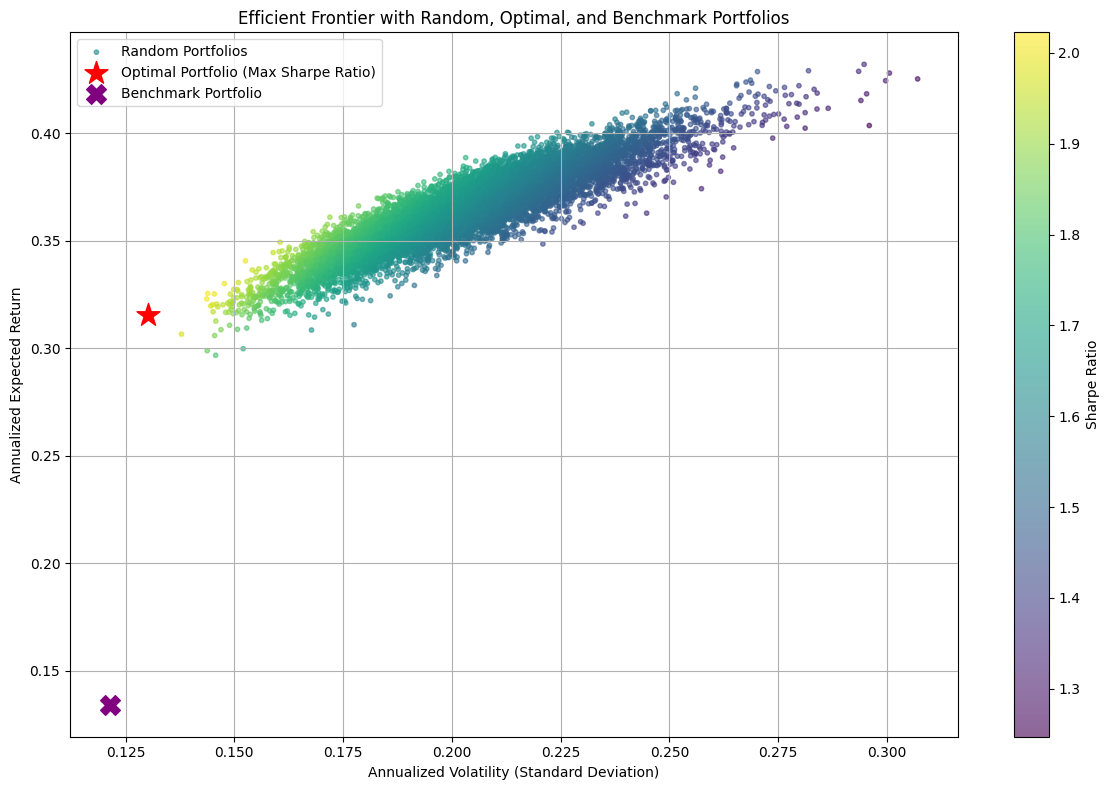


--- Monte Carlo Simulation (Bootstrap) ---


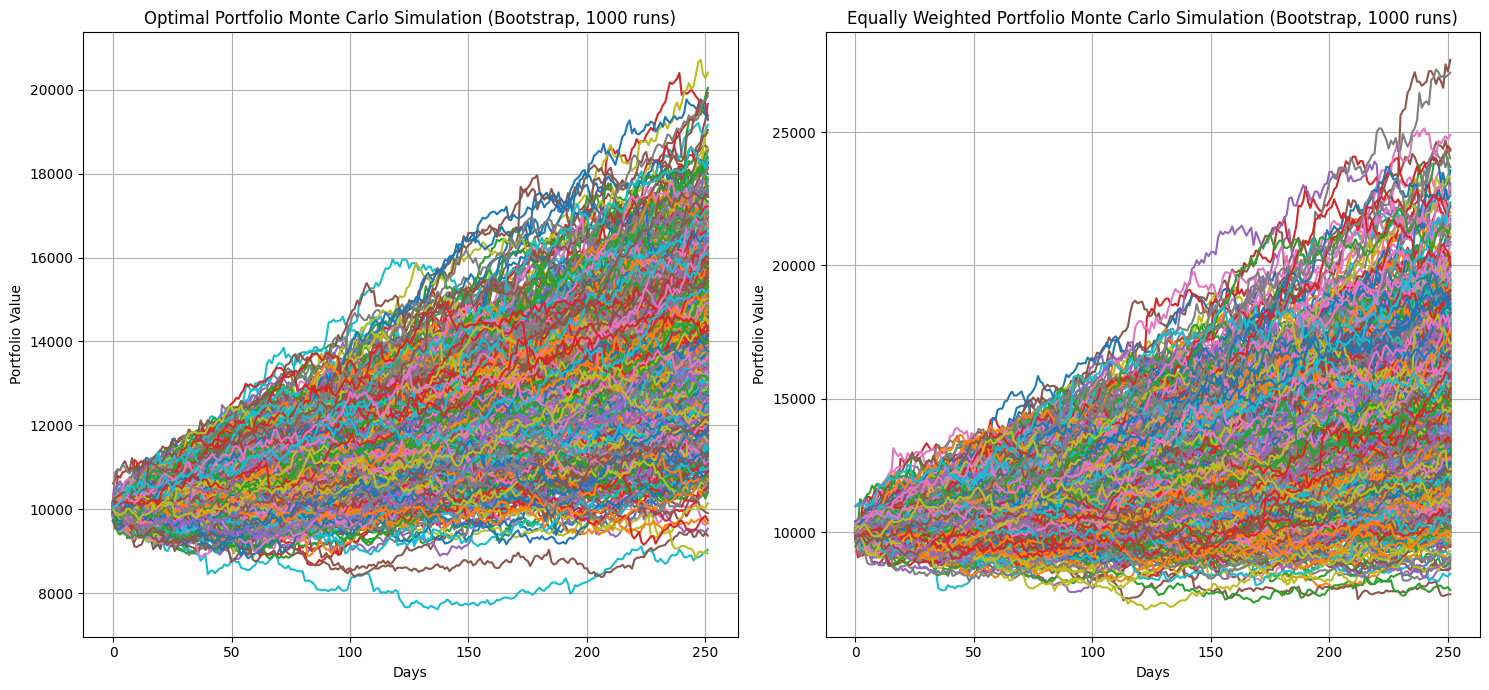


--- Summary Statistics for Final Portfolio Values ---
Optimal Portfolio:
  Mean: $13894.36
  Median: $13758.34
  Standard Deviation: $1843.34
  Minimum: $8944.14
  Maximum: $20409.39

Equally Weighted Portfolio:
  Mean: $14699.44
  Median: $14391.82
  Standard Deviation: $2969.32
  Minimum: $7675.23
  Maximum: $27708.03

--- Comprehensive Portfolio Analysis Complete ---


In [11]:
tickers_for_analysis = top_sharpe_stocks.index.tolist() + ['GLD']
summarize_all_portfolio_analysis(tickers_for_analysis)

Now that we've obtained a dashboard which consist of analyzing two different parameter of wealth management : equally weighted capital and optimally allocated wealth.
Then we define each metrics for each allocation, then the different risk metrics in order to visualize the loss and the risk we occurs using each strategy.
In the last part, in order to outline our strategies in the future, we use a Monte-Carlo simulation to draws perspectives of which portfolio would outperform in the next year.
Finally, we plot a graph which shows us the evolution of the 2 portfolios and the benchmark defined in the IPS.